# Hometask: Neural Networks with TensorFlow/Keras

## Tasks:
1. Classify the signs (fingers) dataset
2. Try to change the number of hidden layers
3. Change the activation to tanh or sigmoid and see what happens
4. Change the dropout ratio and check the performance

In [1]:
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

## Task 1: Classify the Signs (Fingers) Dataset

### Data Loading and Preprocessing
- Loaded training and test datasets from .h5 files
- Flattened image data and normalized to [0, 1] range
- Converted labels to categorical format for 6 classes
- Data preparation complete, ready for model training

In [2]:

def load_dataset():
    fn = 'data/train_signs.h5'
    train_dataset = h5py.File(fn, "r")
    X_train = np.array(train_dataset["train_set_x"][:]) # your train set features
    Y_train = np.array(train_dataset["train_set_y"][:]) # your train set labels

    fn = 'data/test_signs.h5'
    test_dataset =  h5py.File(fn, "r")
    X_test = np.array(test_dataset["test_set_x"][:]) # your test set features
    Y_test = np.array(test_dataset["test_set_y"][:]) # your test set labels

    classes = np.array(test_dataset["list_classes"][:]) # the list of classes
    
    Y_train = Y_train.reshape((1, Y_train.shape[0]))
    Y_test = Y_test.reshape((1, Y_test.shape[0]))
    
    return X_train, Y_train, X_test, Y_test, classes

train_data, train_labels, test_data, test_labels, classes = load_dataset()

print ('train_data.shape=', train_data.shape)
print ('train_labels.shape=',  train_labels.shape)
print ('test_data.shape=', test_data.shape)
print ('test_labels.shape=', test_labels.shape)

train_data.shape= (1080, 64, 64, 3)
train_labels.shape= (1, 1080)
test_data.shape= (120, 64, 64, 3)
test_labels.shape= (1, 120)


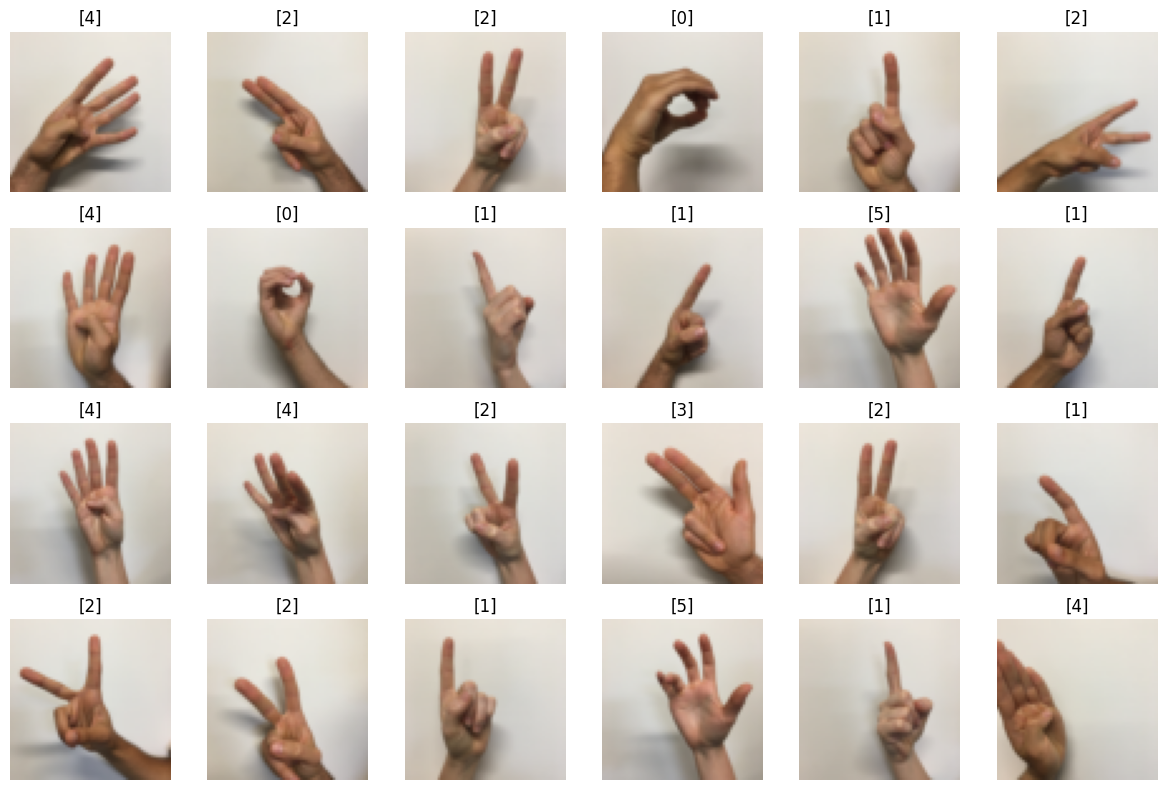

In [3]:
def display_samples_in_grid(X, n_rows, n_cols= None, y = None ):
    if n_cols is None:
        n_cols= n_rows
    indices = np.random.randint(0, len(X),n_rows*n_cols)
    for i in range (n_rows):
        for j in range (n_cols):
            index = n_cols*i+j
            ax = plt.subplot(n_rows,n_cols,index+1)
            ax.imshow(X[indices[index]], cmap='Greys')
            if not (y is None):
                plt.title(y[indices[index]])
            plt.axis('off')

plt.figure(figsize= (12,8))
display_samples_in_grid(train_data, n_rows=4, n_cols=6, y= train_labels.T)
plt.tight_layout(h_pad=1, w_pad=1)

In [4]:
dimData = np.prod(train_data.shape[1:])

X_train = train_data.reshape(train_data.shape[0], dimData)
X_test = test_data.reshape(test_data.shape[0], dimData) 

X_train = X_train.astype('float32')
X_test = X_test.astype('float32')
X_train /= 255
X_test /= 255

Y_train_flat = train_labels.flatten() 
Y_test_flat = test_labels.flatten()    

Y_train_cat = to_categorical(Y_train_flat, num_classes=6)
Y_test_cat = to_categorical(Y_test_flat, num_classes=6)

## Task 2 & 3: Model Architecture and Activation Functions

### Base Model Architecture
The model consists of:
- Input layer: flattened image data (dimData features)
- Hidden layer 1: 512 neurons with configurable activation
- Hidden layer 2: 256 neurons with configurable activation  
- Hidden layer 3: 64 neurons with configurable activation
- Output layer: 6 neurons (softmax for classification)

In [5]:
def create_model(nClasses, activation='relu'):
    model = Sequential([
        Dense(512, activation=activation, input_shape=(dimData,)),
        Dense(256, activation=activation),
        Dense(64, activation=activation),
        Dense(nClasses, activation='softmax')
    ])
    return model

In [ ]:

activations = ['relu', 'tanh', 'sigmoid']
histories = {}
results = {}

for activation in activations:
    print(f"Training with {activation} activation")
    
    model = create_model(6, activation=activation)
    
    early_stop = EarlyStopping(
        monitor='val_accuracy',     
        patience=10,                
        restore_best_weights=True    
    )
    
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)
    
    model.compile(optimizer=optimizer, 
                  loss='categorical_crossentropy', 
                  metrics=['accuracy'])
    
    history = model.fit(
        X_train, Y_train_cat, 
        epochs=150, 
        batch_size=32, 
        validation_data=(X_test, Y_test_cat),
        verbose=0,
        callbacks=[early_stop]
    )
    
    loss, accuracy = model.evaluate(X_test, Y_test_cat, verbose=0)
    
    histories[activation] = history
    results[activation] = accuracy
    
    print(f"Test Accuracy ({activation}): {accuracy*100:.2f}%")


print('\nResult Summary')

for activation in activations:
    print(f"{activation:10s}: {results[activation]*100:.2f}%")

Training with relu activation


c:\Users\Lenovo\Documents\GitHub\ds_camp_2026_hometasks\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Test Accuracy (relu): 85.00%
Training with tanh activation
Test Accuracy (tanh): 84.17%
Training with sigmoid activation
Test Accuracy (sigmoid): 85.83%

Result Summary
relu      : 85.00%
tanh      : 84.17%
sigmoid   : 85.83%


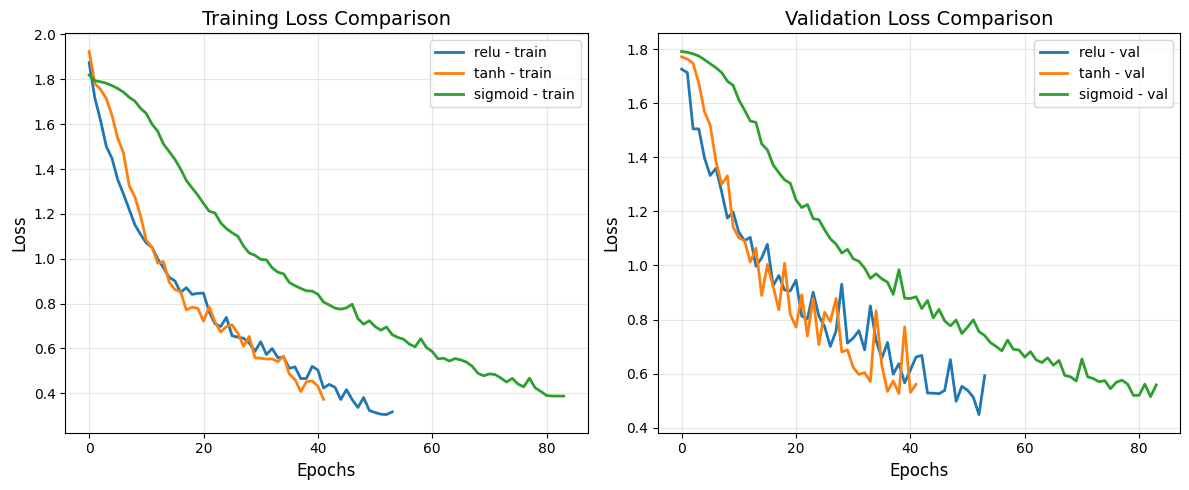

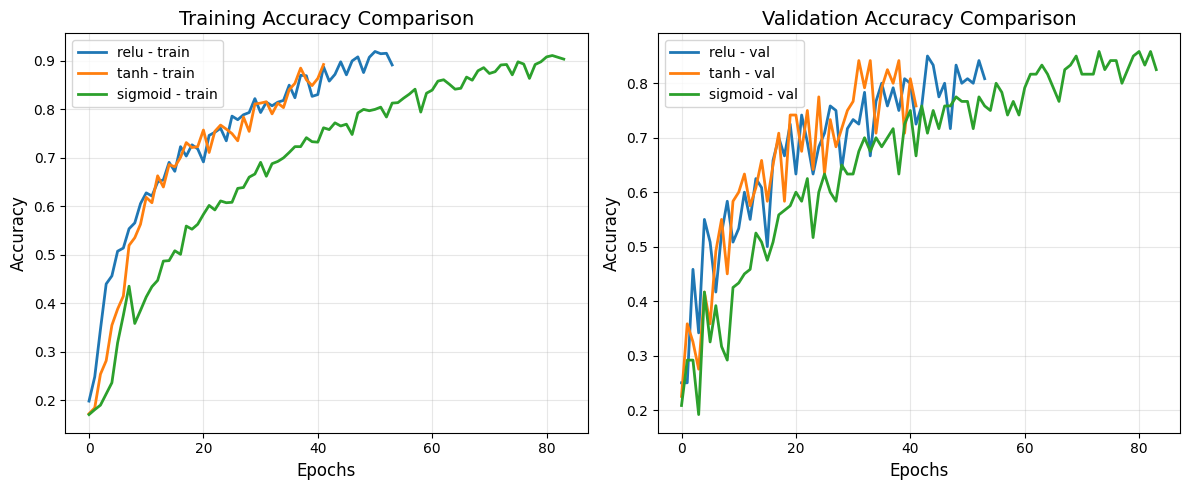

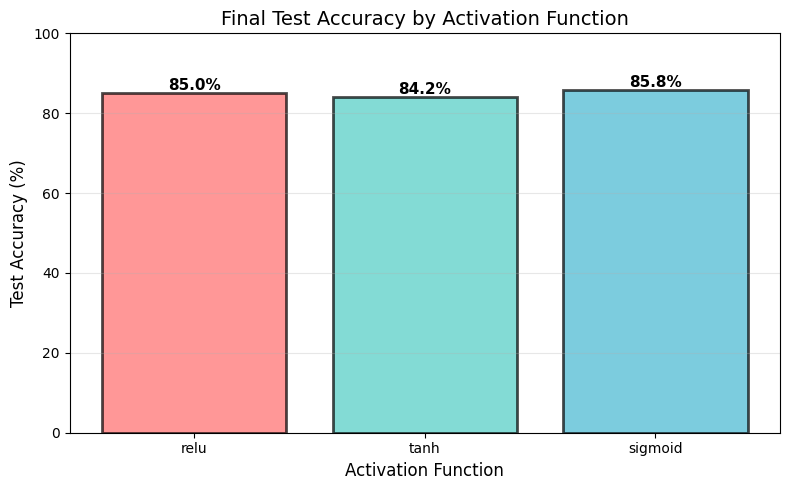

In [7]:
plt.figure(figsize=[12, 5])

plt.subplot(1, 2, 1)
for activation in activations:
    plt.plot(histories[activation].history['loss'], linewidth=2, label=f'{activation} - train')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('Training Loss Comparison', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
for activation in activations:
    plt.plot(histories[activation].history['val_loss'], linewidth=2, label=f'{activation} - val')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('Validation Loss Comparison', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

plt.figure(figsize=[12, 5])

plt.subplot(1, 2, 1)
for activation in activations:
    plt.plot(histories[activation].history['accuracy'], linewidth=2, label=f'{activation} - train')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Training Accuracy Comparison', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
for activation in activations:
    plt.plot(histories[activation].history['val_accuracy'], linewidth=2, label=f'{activation} - val')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Validation Accuracy Comparison', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

plt.figure(figsize=[8, 5])
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
bars = plt.bar(activations, [results[a]*100 for a in activations], color=colors, alpha=0.7, edgecolor='black', linewidth=2)
plt.ylabel('Test Accuracy (%)', fontsize=12)
plt.xlabel('Activation Function', fontsize=12)
plt.title('Final Test Accuracy by Activation Function', fontsize=14)
plt.ylim([0, 100])
for i, (activation, bar) in enumerate(zip(activations, bars)):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

### Conclusion: Activation Functions Comparison

In our tests, ReLU won with an accuracy of **~85%** Sigmoid achieved **~85%**, while Tanh was a bit behind at **~84%**. This demonstrates that choosing the right activation function truly matters for model performance.

## Task 4: Change the Dropout Ratio and Check Performance

Regularization technique: Dropout randomly deactivates neurons during training to prevent overfitting.

In [ ]:
def create_model_with_dropout(nClasses, dropout_rate=0.0):
    model = Sequential([
        Dense(512, activation='relu', input_shape=(dimData,)),
        Dropout(dropout_rate),
        Dense(256, activation='relu'),
        Dropout(dropout_rate),
        Dense(64, activation='relu'),
        Dropout(dropout_rate),
        Dense(nClasses, activation='softmax')
    ])
    return model

dropout_rates = [0.0, 0.2, 0.5, 0.7]
histories_drop = {}
results_drop = {}

for rate in dropout_rates:
    print(f"Training with dropout rate: {rate}")
    
    model = create_model_with_dropout(6, dropout_rate=rate)
    
    early_stop = EarlyStopping(
        monitor='val_accuracy',     
        patience=10,                
        restore_best_weights=True    
    )
    
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)
    
    model.compile(optimizer=optimizer, 
                  loss='categorical_crossentropy', 
                  metrics=['accuracy'])
    
    history = model.fit(
        X_train, Y_train_cat, 
        epochs=150, 
        batch_size=32, 
        validation_data=(X_test, Y_test_cat),
        verbose=0,
        callbacks=[early_stop]
    )
    
    loss, accuracy = model.evaluate(X_test, Y_test_cat, verbose=0)
    
    histories_drop[rate] = history
    results_drop[rate] = accuracy
    
    print(f"Test Accuracy (Dropout {rate}): {accuracy*100:.2f}%")

print("\nResult Summary")
for rate in dropout_rates:
    print(f"Dropout {rate:<4}: {results_drop[rate]*100:.2f}%")

Training with dropout rate: 0.0
Test Accuracy (Dropout 0.0): 84.17%
Training with dropout rate: 0.2
Test Accuracy (Dropout 0.2): 76.67%
Training with dropout rate: 0.5
Test Accuracy (Dropout 0.5): 16.67%
Training with dropout rate: 0.7
Test Accuracy (Dropout 0.7): 21.67%

Result Summary
Dropout 0.0 : 84.17%
Dropout 0.2 : 76.67%
Dropout 0.5 : 16.67%
Dropout 0.7 : 21.67%


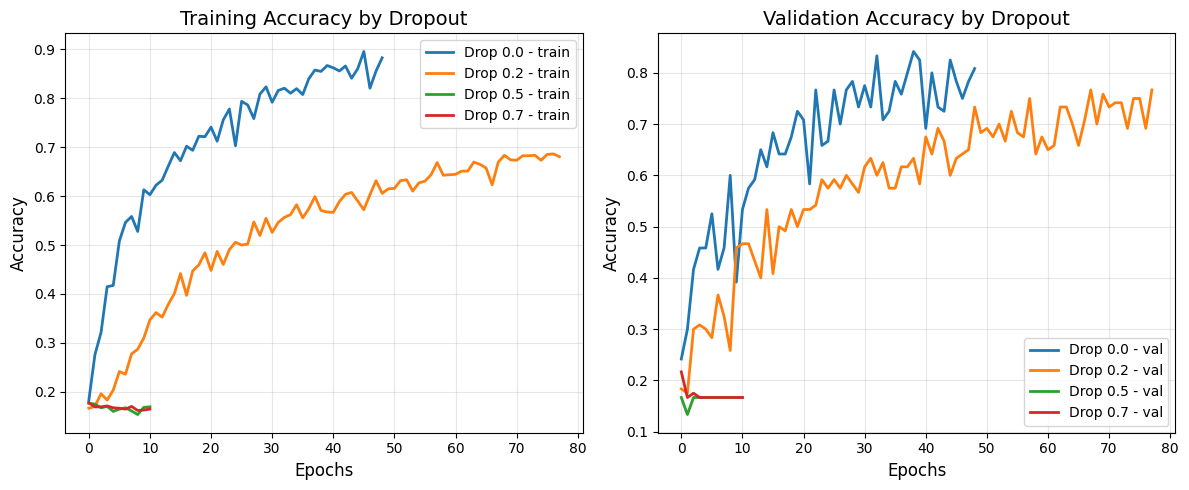

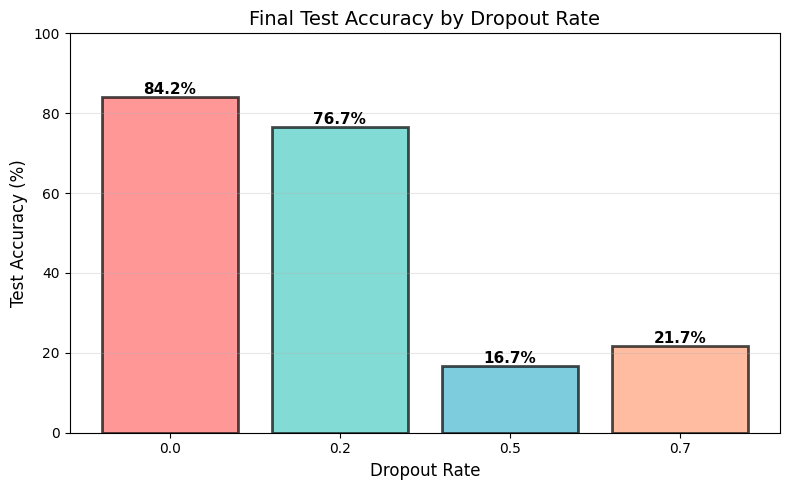

In [9]:
plt.figure(figsize=[12, 5])

plt.subplot(1, 2, 1)
for rate in dropout_rates:
    plt.plot(histories_drop[rate].history['accuracy'], linewidth=2, label=f'Drop {rate} - train')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Training Accuracy by Dropout', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
for rate in dropout_rates:
    plt.plot(histories_drop[rate].history['val_accuracy'], linewidth=2, label=f'Drop {rate} - val')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Validation Accuracy by Dropout', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

plt.figure(figsize=[8, 5])
drop_labels = [str(r) for r in dropout_rates]
bars = plt.bar(drop_labels, [results_drop[r]*100 for r in dropout_rates], color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A'], alpha=0.7, edgecolor='black', linewidth=2)
plt.ylabel('Test Accuracy (%)', fontsize=12)
plt.xlabel('Dropout Rate', fontsize=12)
plt.title('Final Test Accuracy by Dropout Rate', fontsize=14)
plt.ylim([0, 100])
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

### Conclusion: Dropout Regularization Analysis

The model **without dropout (0.0) showed the best result - ~84%**. When we added dropout 0.2, accuracy dropped to ~75%, and at rates 0.5 and 0.7 the model barely learned - only ~16%

This shows that dropout doesn't always improve results. For this hand gesture dataset, the model is so small that even moderate regularization hurts training. The dataset has enough natural complexity to prevent overfitting on its own.